# Treinar CNN para classificar o conjunto de dados Cifar-10 (Imagens)
> Adaptado da seção [*Image Classification Fundamentals*](https://mjrovai.github.io/EdgeML_Made_Ease_ebook/raspi/image_classification/image_classification_fund.html) do [Prof. Marcelo Rovai](https://github.com/Mjrovai) no livro [*EdgeML Made Easy*](https://mjrovai.github.io/EdgeML_Made_Ease_ebook/) e do repositório do GitHub [Edge Machine Learning Systems Engineering](https://github.com/Mjrovai/UNIFEI-IESTI05-EDGE_AI/tree/main).


<table align="left">
  <td>
    <a href="https://colab.research.google.com/github/fabiobento/sis-emb-2025-2/blob/main/aulas/sbc-rpi/rpi_img_class_tflite/docs/4_CNN_Cifar_10_TFLite.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>
  </td>
  <td>
    <a target="_blank" href="https://kaggle.com/kernels/welcome?src=https://github.com/fabiobento/sis-emb-2025-2/blob/main/aulas/sbc-rpi/rpi_img_class_tflite/docs/4_CNN_Cifar_10_TFLite.ipynb"><img src="https://kaggle.com/static/images/open-in-kaggle.svg" /></a>
  </td>
</table>

Nesse notebook vamos fazer classificação das classes do [CIFAR](https://www.cs.toronto.edu/~kriz/cifar.html) (“avião”, “automóvel”, “pássaro”, “gato”, “cervo”, “cão”, “sapo”, “cavalo”, “navio” e “caminhão”). 
- O CIFAR é composto por imagens coloridas de 32x32 (3 canais de cor).
- As imagens do CIFAR não são centralizadas e podem ter o objeto com um fundo, como aviões que podem ter um céu nublado atrás deles!

## Importar bibliotecas necessárias

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPool2D, Flatten
from tensorflow.keras.callbacks import EarlyStopping

2025-10-27 15:48:15.174387: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-10-27 15:48:15.182831: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1761590895.193593  151782 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1761590895.196803  151782 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1761590895.204931  151782 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

## Importar e inspecionar o conjunto de dados CIFAR-10

A página do conjunto de dados Cifar-10 é: https://www.cs.toronto.edu/~kriz/cifar.html

In [4]:
# Importa o módulo do dataset CIFAR-10 de dentro da biblioteca Keras,
# que faz parte do TensorFlow. A variável 'cifar10' agora serve como um atalho
# para acessar as funções relacionadas a este dataset.
cifar10 = tf.keras.datasets.cifar10

# Chama a função load_data() para baixar (se necessário) e carregar o dataset CIFAR-10.
# A função retorna os dados já divididos em dois conjuntos: um para treino e outro para teste.
# Esses dados são desempacotados em quatro variáveis:
#   - train_images: Imagens usadas para treinar o modelo.
#   - train_labels: Rótulos (respostas corretas) correspondentes às imagens de treino.
#   - test_images: Imagens usadas para avaliar o desempenho do modelo após o treino.
#   - test_labels: Rótulos correspondentes às imagens de teste.
(train_images, train_labels), (test_images, test_labels) = cifar10.load_data()

In [6]:
# Imprime as dimensões (formato) dos dados de treino.
# train_images.shape: Mostra (quantidade de imagens, altura, largura, canais de cor).
# train_labels.shape: Mostra (quantidade de rótulos, 1).
print(train_images.shape, train_labels.shape)

# Imprime as dimensões (formato) dos dados de teste.
# A lógica é a mesma dos dados de treino.
print(test_images.shape, test_labels.shape)

(50000, 32, 32, 3) (50000, 1)
(10000, 32, 32, 3) (10000, 1)



- O formato dos dados da imagem é: `(#imagens, altura_da_imagem, largura_da_imagem, #canais)`, onde os canais estão no formato RGB (vermelho, verde, azul).
- O formato dos rótulos é `(#imagens, rótulo)`, onde o rótulo varia de 0 a 9.
11


In [ ]:
# Acessa e exibe o conteúdo da primeira imagem do conjunto de dados de treino.
# Em programação, a contagem de elementos (indexação) começa em 0,
# então '[0]' se refere ao primeiro item.
# A saída será um array NumPy tridimensional representando os pixels
# da imagem (altura, largura, canais de cor RGB).
train_images[1]

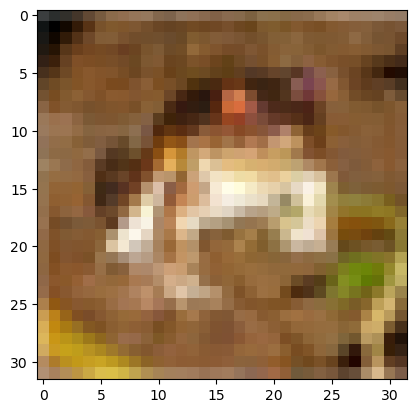

In [ ]:
# Utiliza a função 'imshow' da biblioteca Matplotlib (com o apelido 'plt')
# para exibir uma imagem específica do conjunto de dados de treino.
# O [1] seleciona a segunda imagem da coleção (pois a contagem em programação começa em 0).
# O ponto e vírgula (;) no final é opcional e serve para ocultar a saída de texto
# da função no notebook, mostrando apenas a imagem.
plt.imshow(train_images[1]);

In [ ]:
# Acessa o rótulo (a resposta correta) da segunda imagem do conjunto de treino.
# O primeiro índice [1] seleciona o segundo elemento da lista de rótulos.
# O segundo índice [0] é usado para extrair o valor numérico de dentro do
# array retornado (ex: para obter o número 9 do array [9]).
train_labels[1][0]

np.uint8(6)

Os rótulos CIFAR são matrizes, e é por isso que você precisa de mais um índice para acessar o valor real do rótulo.    

In [16]:
# Cria uma lista com os nomes das 10 classes de objetos do dataset CIFAR-10.
# A ordem dos nomes na lista corresponde aos rótulos numéricos do dataset
# (ex: a classe 0 é 'airplane', a classe 1 é 'automobile', e assim por diante),
# permitindo a tradução dos resultados do modelo para algo legível.
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

In [22]:
# Acessa o elemento na décima posição da lista 'class_names' (índice 9).
# Como a ordem da lista corresponde aos rótulos numéricos, este comando
# "traduz" o rótulo número 9 para o seu nome correspondente, que é 'truck'.
class_names[9]

'truck'

In [ ]:
# 'train_labels[1]' acessa o segundo rótulo, e '[0]' extrai o valor
# numérico de dentro do array (por exemplo, o número 9).
# A variável 'idx' agora armazena esse número.
idx = train_labels[1][0]

#Usa o rótulo numérico ('idx') como índice para encontrar o nome
# da classe correspondente na lista 'class_names'.
# Isso efetivamente "traduz" o número da classe para um nome legível.
class_names[idx]

'truck'

		 truck


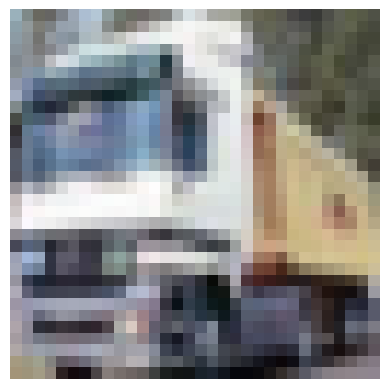

In [27]:
print("\t\t", class_names[train_labels[1][0]])
plt.imshow(train_images[1])
plt.axis('off');

In [ ]:
# Função para exibir uma imagem de treino.
# A função recebe o índice da imagem ('img') e um tamanho opcional para a figura ('size').
def plot_train_img(img, size=2):
    # Obtém o rótulo numérico da imagem especificada, extraindo o valor do array.
    label = train_labels[img][0]
    
    # Cria uma nova figura para o gráfico com o tamanho definido (padrão 2x2 polegadas).
    plt.figure(figsize=(size,size))
    
    # Imprime o rótulo numérico e o nome da classe correspondente.
    print("Rótulo {} - {}".format(label, class_names[label]))
    
    # Exibe a imagem do conjunto de treino na figura.
    plt.imshow(train_images[img])
    
    # Oculta os eixos x e y do gráfico para uma visualização mais limpa da imagem.
    plt.axis('off')
    
    # Mostra a figura final na tela.
    plt.show()

Rótulo 9 - truck


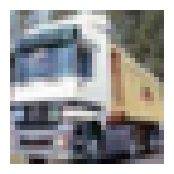

In [29]:
plot_train_img(1)

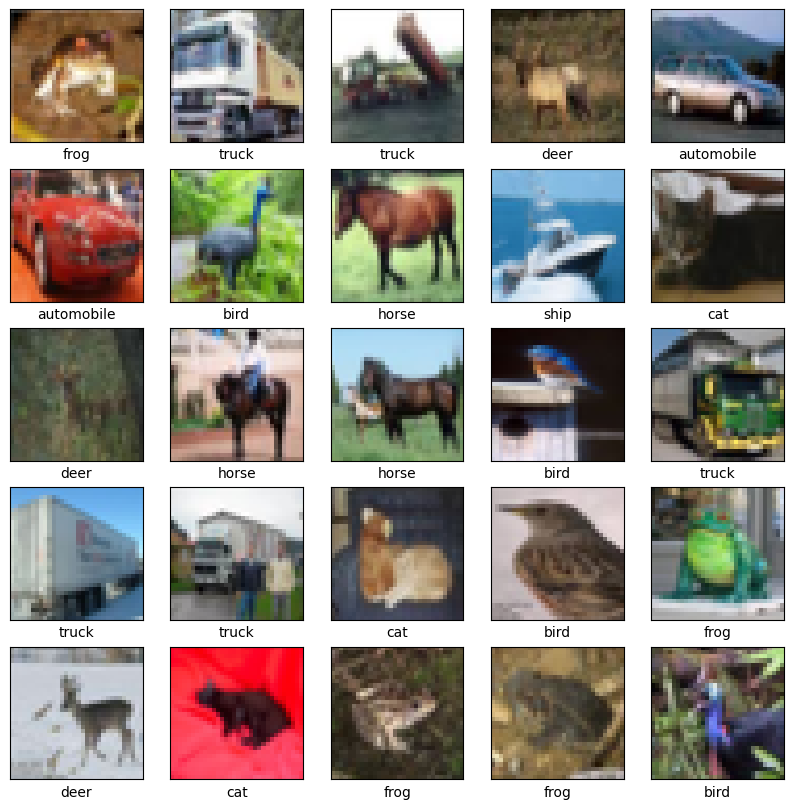

In [ ]:
# Cria uma nova figura para a plotagem com um tamanho total de 10x10 polegadas.
plt.figure(figsize=(10,10))

# Inicia um laço de repetição para exibir as primeiras 25 imagens (índices de 0 a 24).
for i in range(25):
    # Define uma grade de 5x5 subplots e seleciona a posição 'i+1' para a imagem atual.
    plt.subplot(5,5,i+1)
    
    # Remove as marcações numéricas do eixo x para uma visualização mais limpa.
    plt.xticks([])
    
    # Remove as marcações numéricas do eixo y.
    plt.yticks([])
    
    # Desativa as linhas de grade no fundo da imagem.
    plt.grid(False)
    
    # Exibe a i-ésima imagem do conjunto de treino no subplot atual.
    plt.imshow(train_images[i])
    
    # Define o texto abaixo da imagem como o nome da classe correspondente.
    # Para isso, ele pega o rótulo numérico (ex: 9) e usa como índice para
    # encontrar o nome na lista 'class_names' (ex: 'truck').
    plt.xlabel(class_names[train_labels[i][0]])

# Exibe a figura completa com todas as 25 imagens e seus rótulos.
plt.show()

## Preprocessando o conjunto de dados

In [31]:
test_images.max()

np.uint8(255)

In [33]:
# Realiza a normalização dos dados de imagem, uma etapa de pré-processamento.
# Os valores de pixel de uma imagem geralmente vão de 0 (preto) a 255 (branco).
# Dividir todos os pixels por 255.0 transforma essa escala para um intervalo entre 0.0 e 1.0.
# Isso ajuda o modelo de rede neural a aprender de forma mais rápida e estável.

# Normaliza as imagens do conjunto de treino.
train_images = train_images / 255.0

# Normaliza as imagens do conjunto de teste, aplicando a mesma transformação.
test_images = test_images / 255.0

In [32]:
test_images.max()

np.uint8(255)

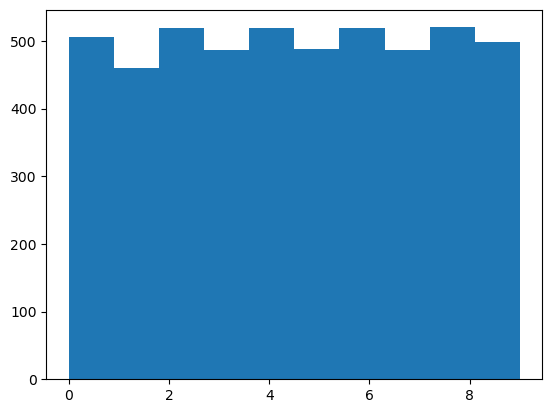

In [ ]:
# Gera um histograma para visualizar a distribuição de classes
# (ou seja, quantas vezes cada rótulo aparece) nas primeiras 5.000 amostras de treino.
# O ponto e vírgula (;) no final é um truque para ocultar a saída de texto
# da função no notebook, exibindo apenas o gráfico.
plt.hist(train_labels[:5_000]);

In [37]:
# Cria um conjunto de validação para as imagens, separando as primeiras 5.000
# amostras do conjunto de treino original. Este novo conjunto será usado para
# monitorar o desempenho do modelo durante o treinamento.
val_images = train_images[:5_000]

# Cria o conjunto de rótulos correspondente para as imagens de validação,
# garantindo que cada imagem tenha sua respectiva resposta correta.
val_labels = train_labels[:5_000]

# Imprime as dimensões (formato) dos novos conjuntos de validação para confirmar
# que a separação foi feita corretamente (deve mostrar 5000 imagens e 5000 rótulos).
print(val_images.shape, val_labels.shape)

(5000, 32, 32, 3) (5000, 1)


In [38]:
# Atualiza o conjunto de imagens de treino, removendo as primeiras 5.000 amostras
# que foram separadas anteriormente para o conjunto de validação.
# A sintaxe '[5_000:]' seleciona todos os elementos a partir do índice 5.000 até o final.
train_images = train_images[5_000:]

# Atualiza o conjunto de rótulos de treino da mesma forma, garantindo que
# os rótulos continuem correspondendo corretamente às imagens.
train_labels = train_labels[5_000:]

# Imprime as novas dimensões (formato) do conjunto de treino para confirmar
# que agora ele possui 45.000 amostras (50.000 originais - 5.000 de validação).
print(train_images.shape, train_labels.shape)

(45000, 32, 32, 3) (45000, 1)


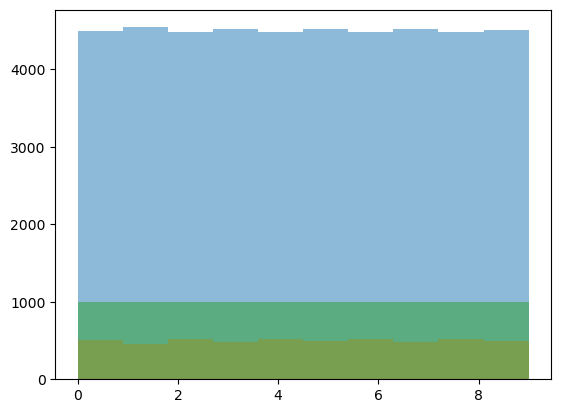

In [39]:
# Cria um histograma para visualizar a distribuição de classes no conjunto de treino.
# 'alpha=0.5' torna as barras do gráfico semitransparentes, facilitando a comparação.
plt.hist(train_labels, alpha=0.5)

# Adiciona ao mesmo gráfico um histograma da distribuição de classes do conjunto de validação.
# A transparência permite ver a sobreposição com o histograma de treino.
plt.hist(val_labels, alpha=0.5)

# Adiciona o histograma do conjunto de teste, completando a comparação entre os três conjuntos.
# O ponto e vírgula (;) no final oculta a saída de texto da função, mostrando apenas o gráfico.
plt.hist(test_labels, alpha=0.5);

## Criar arquitetura do modelo e compilar

Agora utilizademos a API Sequencial do Keras para construir a arquitetura da CNN(*Convolutional Neural Netorks*).
Para aprender um pouco mais confira os seguintes vídeos:
- [Visualizing Convolutional Neural Networks | Layer by Layer](https://www.youtube.com/watch?v=JboZfxUjLSk)
- [Introdução às redes neurais convolucionais (ML de Zero a 100, parte 3)](https://youtu.be/zAfBy74c2AI?t=51)

Em [Camadas de convolução](https://www.tensorflow.org/api_docs/python/tf/keras/layers/Conv2D),
- strides é um número inteiro ou uma tupla/lista de 2 números inteiros, especificando os passos da convolução ao longo da altura e largura. Padrão (1,1).
- padding: um dos valores “valid” ou “same” (sem distinção entre maiúsculas e minúsculas). Padrão = ‘valid’.
- “valid” significa sem preenchimento.
- “same” resulta em preenchimento com zeros uniformemente
à esquerda/direita ou acima/abaixo da entrada, de modo que a saída tenha o mesmo

In [40]:
# Inicializa o modelo como uma pilha sequencial de camadas.
# No Keras, o modelo 'Sequential' é o mais simples: as camadas
# são adicionadas uma após a outra.
model = Sequential()

# --- Bloco Convolucional 1 ---
# Adiciona a primeira camada de convolução, que é a principal camada para
# extrair características de imagens.
model.add(Conv2D(
    filters=32,               # 32 filtros (ou "neurônios") que aprenderão
                              # a detectar diferentes características (bordas, texturas, etc.).
    kernel_size=(3,3),        # Tamanho da janela (kernel) que desliza sobre a imagem (3x3 pixels).
    activation='relu',        # Função de ativação 'ReLU' para introduzir não-linearidade,
                              # o que ajuda o modelo a aprender padrões complexos.
    input_shape=(32, 32, 3))  # Define o formato das imagens de entrada:
                              # 32x32 pixels com 3 canais de cor (RGB).
)
# Adiciona uma camada de Max Pooling para reduzir a dimensão espacial (altura e largura) do
# mapa de características.
# Isso ajuda a tornar o modelo mais eficiente e a focar nas características mais importantes.
model.add(MaxPool2D(2, 2))

# --- Bloco Convolucional 2 ---
# Adiciona uma segunda camada de convolução, agora com 64 filtros, para aprender características
# mais complexas a partir do que foi extraído na camada anterior.
model.add(Conv2D(64, (3,3), activation='relu'))
# Adiciona outra camada de Max Pooling para continuar reduzindo as dimensões.
model.add(MaxPool2D())

# --- Bloco de Classificação ---
# "Achata" a saída do bloco anterior, transformando a matriz 2D de características em um único vetor 1D.
# Isso prepara os dados para serem processados pelas camadas densas (totalmente conectadas).
model.add(Flatten())

# Adiciona uma camada densa (fully-connected) com 64 neurônios para aprender combinações
# das características extraídas.
model.add(Dense(64, activation='relu'))

# Adiciona a camada de saída final, que fará a classificação.
# Possui 10 neurônios, um para cada uma das 10 classes do CIFAR-10.
# A função de ativação 'softmax' converte a saída dos neurônios em uma distribuição
# de probabilidade, indicando a chance de a imagem pertencer a cada classe.
model.add(Dense(10, activation='softmax'))

# Imprime um resumo da arquitetura do modelo, mostrando todas as camadas,
# o formato de saída de cada uma e o número total de parâmetros a serem treinados.
model.summary()

/home/fabio/anaconda3/envs/tf_env/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1761592568.068514  151782 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9856 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060, pci bus id: 0000:01:00.0, compute capability: 8.6


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       147,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 167,562 (654.54 KB)

 Trainable params: 167,562 (654.54 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Define a função de perda (loss function) que será utilizada para treinar o modelo.
# 'sparse_categorical_crossentropy' é ideal para problemas de classificação com múltiplas classes
# onde os rótulos (labels) são números inteiros (como 0, 1, 2...), e não vetores "one-hot".
# Essa função calcula o quão "errada" a previsão do modelo está em comparação com a resposta correta.
LOSS = 'sparse_categorical_crossentropy'

# Define o otimizador, que é o algoritmo responsável por ajustar os pesos da rede neural
# para minimizar a função de perda. 'adam' é um otimizador muito popular e eficiente,
# conhecido por sua boa performance na maioria dos casos.
OPTIMIZER = 'adam'

# Compila o modelo, configurando-o para o processo de treinamento.
# Este passo "monta" o modelo com as configurações definidas.
model.compile(optimizer=OPTIMIZER,  # Define o algoritmo que o modelo usará para aprender.
              loss=LOSS,          # Define a métrica que o modelo tentará minimizar.
              metrics=['accuracy']) # Define a métrica que será usada para avaliar o desempenho do modelo
                                    # durante o treino e teste (neste caso, a acurácia).

## Treinando o modelo

In [ ]:
# Define o número de épocas para o treinamento do modelo.
# Uma "época" representa uma passagem completa por todo o conjunto de dados de treino.
# Neste caso, o modelo verá todos os dados de treino 20 vezes.
NUM_EPOCHS = 20

# Configura um "callback" chamado EarlyStopping (Parada Antecipada).
# Este mecanismo monitora o desempenho do modelo e interrompe o treinamento
# automaticamente se não houver melhora, evitando overfitting e economizando tempo.
early_stop = EarlyStopping(
    monitor='val_loss',  # Monitora a perda ('loss') no conjunto de dados de validação.
    patience=3           # Paciência: interrompe o treino se a 'val_loss' não diminuir por 3 épocas consecutivas.
)

In [ ]:
# Inicia o processo de treinamento do modelo com os dados de treino.
# O método 'fit' ajusta os pesos do modelo para minimizar a perda (loss).
# O resultado do treinamento (histórico de métricas por época) é armazenado na variável 'history'.
history = model.fit(
    train_images,                       # As imagens de entrada que o modelo aprenderá.
    train_labels,                       # Os rótulos (respostas corretas) para as imagens de treino.
    epochs=NUM_EPOCHS,                  # O número máximo de vezes que o modelo passará por todo o dataset de treino.
    validation_data=(val_images, val_labels), # Dados de validação para monitorar o desempenho do modelo
                                              # em dados "novos" ao final de cada época e checar por overfitting.
    callbacks=[early_stop]              # Lista de "callbacks" a serem usados durante o treino.
                                        # Aqui, usamos o 'early_stop' para parar o treino
                                        # se a performance na validação não melhorar.
)

Epoch 1/20


I0000 00:00:1761592663.074091  162086 service.cc:152] XLA service 0x7a62e000ba10 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1761592663.074108  162086 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 3060, Compute Capability 8.6
2025-10-27 16:17:43.089538: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1761592663.185982  162086 cuda_dnn.cc:529] Loaded cuDNN version 90101


 111/1407 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.1800 - loss: 2.2026

I0000 00:00:1761592664.594027  162086 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.4656 - loss: 1.4913 - val_accuracy: 0.5798 - val_loss: 1.2147
Epoch 2/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.6016 - loss: 1.1332 - val_accuracy: 0.6062 - val_loss: 1.1031
Epoch 3/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.6570 - loss: 0.9882 - val_accuracy: 0.6544 - val_loss: 0.9791
Epoch 4/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.6884 - loss: 0.8968 - val_accuracy: 0.6768 - val_loss: 0.9468
Epoch 5/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7090 - loss: 0.8332 - val_accuracy: 0.6780 - val_loss: 0.9239
Epoch 6/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7315 - loss: 0.7756 - val_accuracy: 0.6836 - val_loss: 0.9154
Epoch 7/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7462 - loss: 0.7264 - val_accuracy: 0.6782 - val_loss: 0.9408
Epoch 8/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7628 - loss: 0.6838 - val_accurac

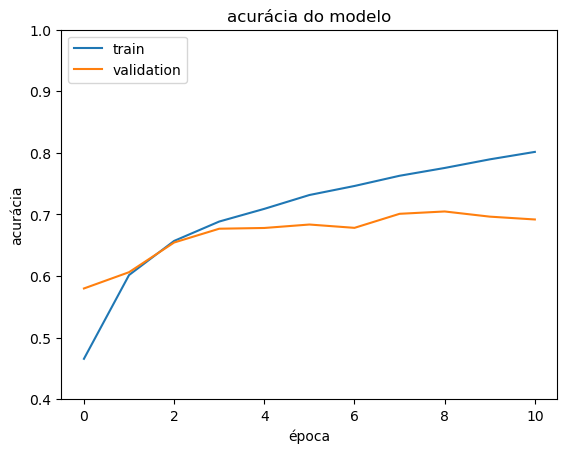

In [ ]:
# --- Visualização do Histórico de Acurácia ---

# Cria um gráfico de linha para a acurácia do modelo no conjunto de TREINO ao longo das épocas.
# 'history.history['accuracy']' acessa a lista de valores de acurácia de treino registrados a cada época.
plt.plot(history.history['accuracy'])

# Adiciona ao mesmo gráfico a linha da acurácia no conjunto de VALIDAÇÃO.
# Isso permite comparar o desempenho do modelo em dados de treino versus dados "novos".
plt.plot(history.history['val_accuracy'])

# Define o título principal do gráfico.
plt.title('Acurácia do modelo')

# Define o rótulo do eixo Y (vertical).
plt.ylabel('Acurácia')

# Define o rótulo do eixo X (horizontal).
plt.xlabel('Época')

# Adiciona uma legenda ao gráfico para identificar qual linha corresponde a qual dado ('train' ou 'validation').
# 'loc='upper left'' posiciona a legenda no canto superior esquerdo.
plt.legend(['Treino', 'Validação'], loc='upper left')

# (Linha comentada) Limitaria o eixo X para mostrar todas as épocas, do início ao fim.
#plt.xlim([0,NUM_EPOCHS])

# Define os limites do eixo Y, ajustando o "zoom" do gráfico para focar no intervalo de acurácia entre 40% e 100%.
plt.ylim([0.4, 1.0])

# Exibe o gráfico final na tela.
plt.show()

## Avaliar o modelo

In [ ]:
# Avalia o desempenho final do modelo no conjunto de dados de teste.
# Este passo é crucial para verificar se o modelo consegue generalizar o que aprendeu
# para dados completamente novos, que não foram usados no treino nem na validação.
# A função retorna uma lista com os valores finais da perda (loss) e da acurácia (accuracy).
model.evaluate(test_images, test_labels)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6876 - loss: 0.9868


[0.986765444278717, 0.6876000165939331]

**Acurácia**
- Treino: 85% - 90%;
- Validação: 68%-70%
- Teste: 66%-68%

In [ ]:
# Usa o modelo treinado para fazer previsões em todas as imagens do conjunto de teste.
# 1. model.predict(test_images): Gera um array de probabilidades para cada imagem (ex: [0.1, 0.05, ..., 0.8]).
# 2. np.argmax(..., axis=-1): Encontra o índice da maior probabilidade em cada previsão,
#    que corresponde ao rótulo da classe prevista (ex: 5).
# O resultado é um array contendo o rótulo numérico previsto para cada imagem de teste.
predictions = np.argmax(model.predict(test_images), axis=-1)

# Imprime as dimensões (formato) do array de previsões para verificação.
# O resultado deve ser (10000,), confirmando que temos uma previsão para cada uma das 10.000 imagens de teste.
predictions.shape

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


(10000,)

In [ ]:
# Importa do módulo 'metrics' da biblioteca Scikit-learn duas funções essenciais
# para a avaliação de modelos de classificação:
#   - classification_report: Gera um relatório de texto com as principais métricas
#     (precisão, recall, f1-score) para cada classe.
#   - confusion_matrix: Cria uma matriz de confusão para visualizar os acertos e
#     erros do modelo, mostrando quais classes estão sendo confundidas entre si.
from sklearn.metrics import classification_report, confusion_matrix

In [49]:
print(classification_report(test_labels, predictions, target_names=class_names))

              precision    recall  f1-score   support

    airplane       0.73      0.71      0.72      1000
  automobile       0.79      0.80      0.80      1000
        bird       0.52      0.66      0.58      1000
         cat       0.53      0.49      0.51      1000
        deer       0.66      0.64      0.65      1000
         dog       0.52      0.67      0.59      1000
        frog       0.79      0.77      0.78      1000
       horse       0.84      0.63      0.72      1000
        ship       0.85      0.74      0.79      1000
       truck       0.78      0.78      0.78      1000

    accuracy                           0.69     10000
   macro avg       0.70      0.69      0.69     10000
weighted avg       0.70      0.69      0.69     10000



In [50]:
confusion_matrix(test_labels,predictions)

array([[714,  33, 104,  21,  16,  16,   9,   7,  47,  33],
       [ 20, 801,  10,  13,   6,  15,   5,   6,  19, 105],
       [ 49,   7, 658,  57,  66,  84,  42,  22,  10,   5],
       [ 26,   9,  99, 488,  61, 220,  56,  17,   8,  16],
       [ 22,   4, 120,  51, 638,  70,  52,  34,   7,   2],
       [ 12,   3,  83, 151,  38, 665,  19,  16,   6,   7],
       [  7,   4,  86,  52,  24,  48, 765,   3,   8,   3],
       [ 15,   4,  67,  40,  96, 124,   8, 631,   2,  13],
       [ 82,  60,  35,  21,  14,  14,   4,   2, 738,  30],
       [ 32,  87,  10,  21,  11,  16,   9,  10,  26, 778]])

In [51]:
class_names

['airplane',
 'automobile',
 'bird',
 'cat',
 'deer',
 'dog',
 'frog',
 'horse',
 'ship',
 'truck']

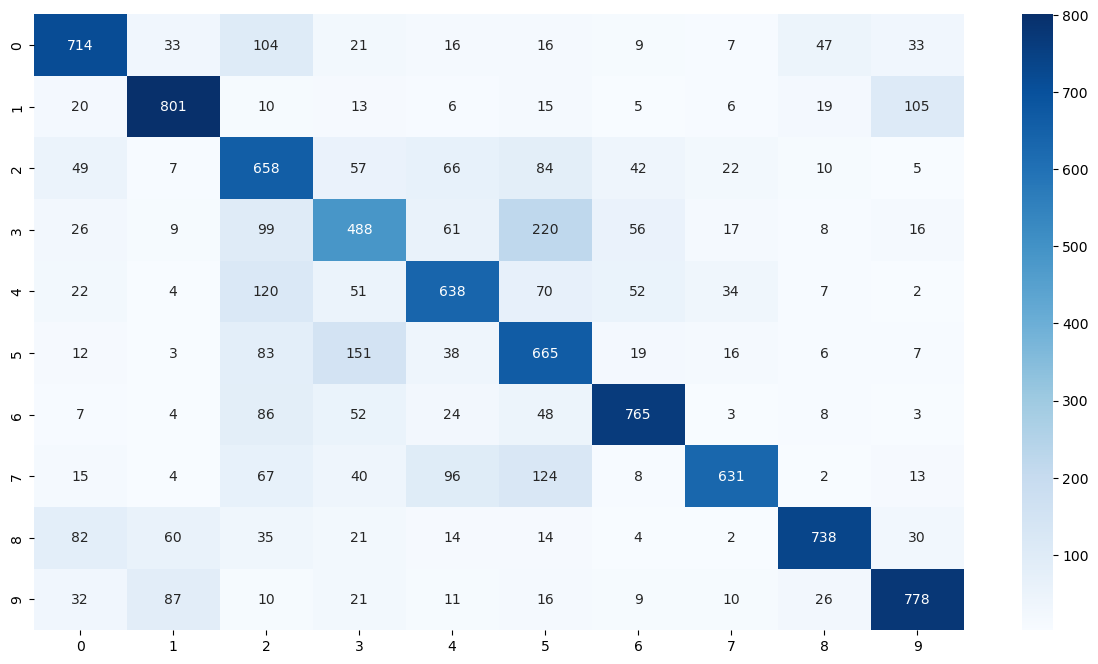

In [55]:
import seaborn as sns
plt.figure(figsize=(15,8))
sns.heatmap(confusion_matrix(test_labels,predictions), cmap='Blues', annot=True, fmt='g');

## Testando o modelo (previsão de algumas imagens de teste)

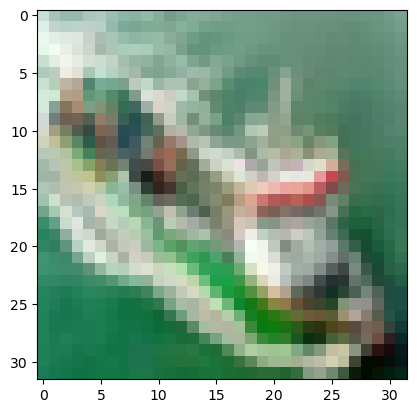

In [56]:
plt.imshow(test_images[15]);

In [57]:
test_labels[15][0]

np.uint8(8)

In [58]:
class_names[8]

'ship'

In [59]:
test_images[15].shape

(32, 32, 3)

A forma do tensor de entrada deve ser: (num_images, largura, altura, canais_de_cor)


In [60]:
my_image = test_images[15]
my_image = my_image.reshape(1,32,32,3)
my_image.shape

(1, 32, 32, 3)

In [61]:
img_pred = np.argmax(model.predict(my_image))
class_names[img_pred]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 274ms/step


'frog'

In [62]:
img_pred

np.int64(6)

In [63]:
pred_prob = model.predict(my_image)[0][img_pred]
pred_prob

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


np.float32(0.5509995)

In [64]:
def img_pred(img, size=4):
    label = test_labels[img][0]
    my_image = test_images[img]
    plt.figure(figsize=(size,size))
    plt.imshow(my_image)
    my_image = my_image.reshape(1,32,32,3)
    img_pred = np.argmax(model.predict(my_image))
    pred_label = class_names[img_pred]
    pred_prob = model.predict(my_image)[0][img_pred]
    print(" Label {} <=> Pred: {} with prob {:.2}".format(
        class_names[label],
        pred_label,
        pred_prob))
    plt.grid(False)
    plt.axis('off')
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
 Label cat <=> Pred: cat with prob 0.86


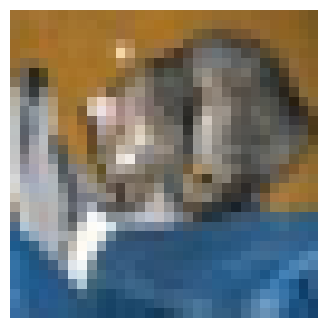

In [66]:
img_pred(0)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
 Label cat <=> Pred: cat with prob 0.86


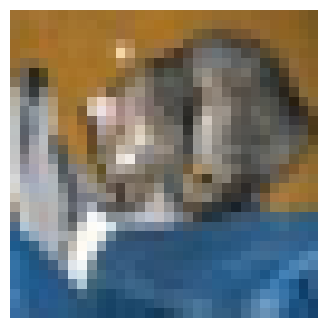

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
 Label ship <=> Pred: automobile with prob 0.74


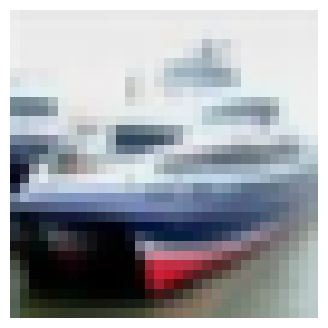

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
 Label ship <=> Pred: airplane with prob 0.49


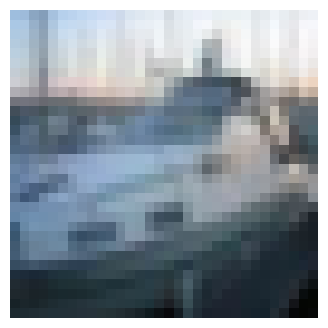

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
 Label airplane <=> Pred: airplane with prob 0.81


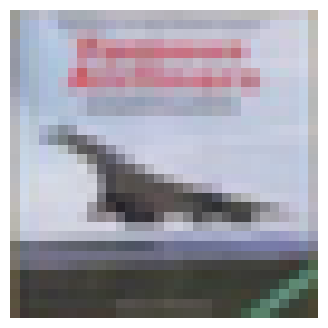

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
 Label frog <=> Pred: frog with prob 0.74


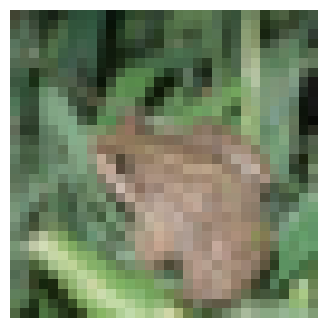

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
 Label frog <=> Pred: frog with prob 0.99


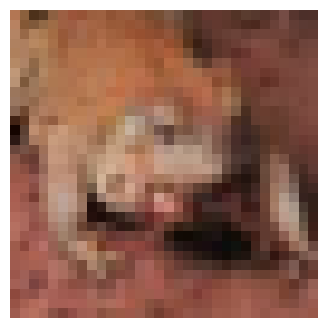

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
 Label automobile <=> Pred: truck with prob 0.55


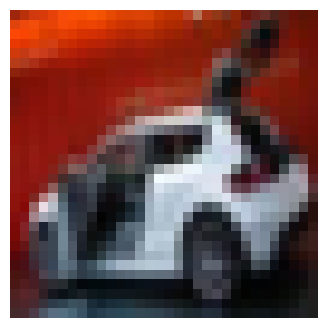

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
 Label frog <=> Pred: bird with prob 0.49


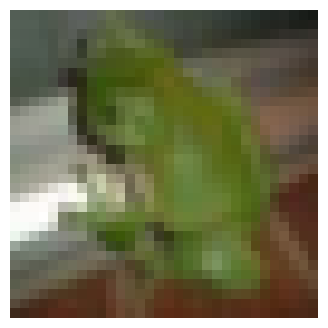

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
 Label cat <=> Pred: cat with prob 0.45


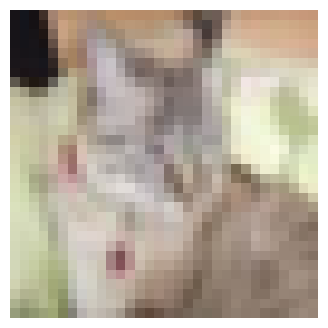

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
 Label automobile <=> Pred: automobile with prob 0.96


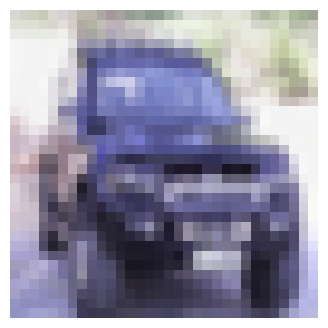

In [65]:
for i in range (10):
  img_pred(i)

## Salvando o modelo treinado

In [67]:
!pwd  # Comando Linux, mostra onde estamos nas pastas do CoLab

/home/fabio/Documentos/vscode/sis-emb-2025-2/aulas/sbc-rpi/rpi_img_class_tflite/docs


In [68]:
model.save('cifar_10_model.h5')

- Use o [Netron](https://netron.app) para visualizar o modelo, hiperparâmetros, formas de sensores, etc.
- O Netron é um visualizador para modelos de redes neurais, aprendizado profundo e aprendizado de máquina (consulte o [GitHub](https://github.com/lutzroeder/netron) para obter instruções sobre a instalação em seu desktop).

# Convertendo o modelo para TFLite

You can convert the TF trained model using:  `TFLiteConverter.from_keras_model(model)`

In [69]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)

Alternativamente, é possível converter o modeloa partir:
- de um modelo salvo.: `tf.lite.TFLiteConverter.from_saved_model(model_cifar10)` ou
- de um modelo Keras: `tf.lite.TFLiteConverter.from_keras_model(model_cifar10.h5)`

In [70]:
# model_path = '/content/cifar_10_model'
# model_cifar10 = tf.keras.models.load_model(model_path)
# converter = tf.lite.TFLiteConverter.from_saved_model(model_cifar10)
# converter = tf.lite.TFLiteConverter.from_keras_model(model_cifar10)

In [71]:
tflite_model = converter.convert()

INFO:tensorflow:Assets written to: /tmp/tmpx52aah67/assets


INFO:tensorflow:Assets written to: /tmp/tmpx52aah67/assets


Saved artifact at '/tmp/tmpx52aah67'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 32, 32, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  134571442894224: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134571442895568: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134571442895376: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134571442893456: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134571442886736: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134571442885392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134571442885776: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134571442885008: TensorSpec(shape=(), dtype=tf.resource, name=None)


W0000 00:00:1761593469.758143  151782 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1761593469.758185  151782 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
2025-10-27 16:31:09.758775: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpx52aah67
2025-10-27 16:31:09.759431: I tensorflow/cc/saved_model/reader.cc:52] Reading meta graph with tags { serve }
2025-10-27 16:31:09.759447: I tensorflow/cc/saved_model/reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmpx52aah67
I0000 00:00:1761593469.764430  151782 mlir_graph_optimization_pass.cc:425] MLIR V1 optimization pass is not enabled
2025-10-27 16:31:09.765434: I tensorflow/cc/saved_model/loader.cc:236] Restoring SavedModel bundle.
2025-10-27 16:31:09.791937: I tensorflow/cc/saved_model/loader.cc:220] Running initialization op on SavedModel bundle at path: /tmp/tmpx52aah67
2025-10-27 16:31:09.798435: I tensorflow/cc/saved_model/loader.cc:471] SavedModel 

In [ ]:
# Salvar o modelo .tflite
open("/content/cifar10.tflite","wb").write(tflite_model)

## Quantização da faixa dinâmica (*Dynamic range quantization*)
A forma mais simples de quantização pós-treinamento quantiza estaticamente apenas os pesos de ponto flutuante para inteiro, que tem 8 bits de precisão:

In [ ]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_quant_model = converter.convert()


In [ ]:
# Salvar o modelo .tflite
open("/content/cifar10_quant.tflite","wb").write(tflite_quant_model)

Use o [Netron](https://netron.app) para visualizar o modelo quantizado. Preste atenção que agora os pesos são int8.

## Carregando um modelo TF salvo para conversão

Se você deseja carregar seu modelo salvo anteriormente para evitar retreiná-lo:

1.   À esquerda da interface do usuário, clique no ícone da pasta e vá para a subpasta “content”.
2.   Clique nos três pontos à direita do arquivo da pasta “content” e selecione upload”.



In [ ]:
model_path = '/content/cifar_10_model.h5'
model_cifar10 = tf.keras.models.load_model(model_path)
converter = tf.lite.TFLiteConverter.from_keras_model(model_cifar10)

In [ ]:
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_quant_model = converter.convert()

In [ ]:
# Salvar o modelo .tflite
tflite_model_size = open("/content/cifar10_quant_model.tflite","wb").write(tflite_quant_model)
print("Quantized model (DEFAULT) is {:,} bytes".format(tflite_model_size))

## Testando o modelo TFLite

In [ ]:
interpreter = tf.lite.Interpreter("/content/cifar10_quant_model.tflite")

In [ ]:
interpreter.allocate_tensors()
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

In [ ]:
input_details

In [ ]:
output_details

In [ ]:
def set_input_tensor(interpreter, image):
    tensor_index = interpreter.get_input_details()[0]['index']
    input_tensor = interpreter.tensor(tensor_index)()[0]
    input_tensor[:, :] = image

In [ ]:
image = test_images[0]
plt.imshow(image);

In [ ]:
set_input_tensor(interpreter, image)
interpreter.invoke()
output_details = interpreter.get_output_details()[0]

In [ ]:
interpreter.get_tensor(output_details['index'])

In [ ]:
np.squeeze(interpreter.get_tensor(output_details['index']))

In [ ]:
output = np.squeeze(interpreter.get_tensor(output_details['index']))
output

In [ ]:
img_pred = np.argmax(output)
class_names[img_pred]

In [ ]:
img_pred

In [ ]:
output[img_pred]

In [ ]:
def classify_image(image):
    set_input_tensor(interpreter, image)
    interpreter.invoke()
    output_details = interpreter.get_output_details()[0]
    output = np.squeeze(interpreter.get_tensor(output_details['index']))
    img_pred = np.argmax(output)
    pred_label = class_names[img_pred]
    pred_prob = output[img_pred]
    plt.imshow(image)
    print(" Pred: {} with prob {:.2}".format(
        pred_label,
        pred_prob))
    plt.grid(False)
    plt.axis('off')
    plt.show()

In [ ]:
classify_image(test_images[0])

In [ ]:
for i in range (10):
  classify_image(test_images[i])

# TensorFlow Lite Micro

In [ ]:
import tensorflow as tf

In [ ]:
model_path = '/content/cifar_10_model.h5'
model_cifar10 = tf.keras.models.load_model(model_path)
converter = tf.lite.TFLiteConverter.from_keras_model(model_cifar10)

In [ ]:
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_quant_model = converter.convert()

In [ ]:
# Salvar o modelo .tflite
tflite_model_size = open("/content/cifar10_quant_model.tflite","wb").write(tflite_quant_model)
print("Quantized model (DEFAULT) is {:,} bytes".format(tflite_model_size))

### Gere um modelo TensorFlow Lite para microcontroladores
Para converter o modelo quantizado TensorFlow Lite em um arquivo fonte C que possa ser carregado pelo TensorFlow Lite para microcontroladores em MCUs, basta usar a ferramenta xxd para converter o arquivo .tflite em um arquivo .cc.

**Converter para um array C**

Primeiro instale o xxd

In [ ]:
!apt-get update && apt-get -qq install xxd

Agora, converta e salve o modelo convertido em .cc.

In [ ]:
MODEL_TFLITE = 'cifar10_quant_model.tflite'
MODEL_TFLITE_MICRO = 'cifar10_quant_model.cc'
!xxd -i {MODEL_TFLITE} > {MODEL_TFLITE_MICRO}
REPLACE_TEXT = MODEL_TFLITE.replace('/', '_').replace('.', '_')
!sed -i 's/'{REPLACE_TEXT}'/g_model/g' {MODEL_TFLITE_MICRO}

Se você deseja baixar seu modelo para mantê-lo em segurança:
1. À esquerda da interface do usuário, clique no ícone da pasta
2. Clique nos três pontos à direita do arquivo ```cifar10_quant_model.cc``` e selecione baixar

In [ ]:
!cat {MODEL_TFLITE_MICRO}